# **6. STGNN**

## **6.1. Librerias**

In [1]:
import os
import copy
import random
import optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

import geopandas as gpd
from libpysal.weights import Queen
import sys
import time


## **6.2. Configuración Reproducibilidad**

In [2]:
SEEDS = [42, 123, 2024]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)

def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True)
    os.environ["PYTHONHASHSEED"] = str(seed)

    print(f"Seed fijada: {seed}")


def seed_worker(worker_id):

    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


g = torch.Generator()

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Python: 3.10.20 (main, Mar  3 2026, 09:24:47) [GCC 13.3.0]
Torch: 2.11.0+cu130
Numpy: 2.2.6
Pandas: 2.3.3


El entorno de ejecución utiliza PyTorch 2.11 con soporte CUDA 13.0 y una GPU NVIDIA GeForce RTX 5050 Laptop, lo que permite acelerar significativamente el entrenamiento de modelos de deep learning. Además, la configuración de semillas múltiples y versiones recientes de librerías como NumPy y Pandas favorece la reproducibilidad y estabilidad experimental.

Este código implementa una estrategia exhaustiva de reproducibilidad en experimentos con PyTorch, fijando semillas en random, numpy y torch, además de desactivar optimizaciones no deterministas de CUDA (como cudnn.benchmark) para garantizar resultados consistentes entre ejecuciones. Asimismo, se controla la aleatoriedad en los *data loaders* mediante seed_worker y un generador de PyTorch, asegurando coherencia en el muestreo paralelo de datos.

## **6.3. Carga de Datos & Preprocesamiento**

### **6.3.1. Carga de Datos**

In [3]:
df = pd.read_csv("/home/guirlessa/Dl_Proyecto_Dengue/Bases_Datos/df_full.csv")
df.head()

,departamento,fecha_inicio,ano,semana,casos,casos_mujeres,casos_hombres,casos_rural,casos_urbano,(0_5],...,precip_lag_12,precip_lag_20,temp_c,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_8,temp_lag_12,temp_lag_20
0,Amazonas,2012-01-02,2012,1,0.0,0,0,0,0,0,...,50.983546,39.108242,24.848668,24.890654,24.334752,24.545618,25.345678,25.278160,25.874930,24.364443
1,Amazonas,2012-01-09,2012,2,0.0,0,0,0,0,0,...,61.818291,62.830250,24.729721,24.848668,24.890654,24.334752,24.545618,25.084141,25.495665,24.971798
2,Amazonas,2012-01-16,2012,3,0.0,0,0,0,0,0,...,24.950393,42.988018,24.638674,24.729721,24.848668,24.890654,24.334752,25.751070,25.760539,25.304947
3,Amazonas,2012-01-23,2012,4,0.0,0,0,0,0,0,...,88.169343,56.572467,25.164008,24.638674,24.729721,24.848668,24.890654,25.284157,25.842089,25.166142
4,Amazonas,2012-01-30,2012,5,0.0,0,0,0,0,0,...,56.271440,74.893047,24.604644,25.164008,24.638674,24.729721,24.848668,25.345678,25.278160,25.312395


In [4]:
print("El dataframe tiene {0} filas y {1} columnas.".format(df.shape[0], df.shape[1]))

El dataframe tiene 21664 filas y 54 columnas.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21664 entries, 0 to 21663
Data columns (total 54 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   departamento        21664 non-null  object 
 1   fecha_inicio        21664 non-null  object 
 2   ano                 21664 non-null  int64  
 3   semana              21664 non-null  int64  
 4   casos               21664 non-null  float64
 5   casos_mujeres       21664 non-null  int64  
 6   casos_hombres       21664 non-null  int64  
 7   casos_rural         21664 non-null  int64  
 8   casos_urbano        21664 non-null  int64  
 9   (0_5]               21664 non-null  int64  
 10  (5_13]              21664 non-null  int64  
 11  (13_26]             21664 non-null  int64  
 12  (26_60]             21664 non-null  int64  
 13  60_mas              21664 non-null  int64  
 14  casos_Contributivo  21664 non-null  int64  
 15  casos_No_asegurado  21664 non-null  int64  
 16  caso

Se observa que la variable `fecha_inicio` está tipificada como `object`, cuando en realidad debería corresponder al tipo `datetime`. Por ello, se procederá a realizar la conversión adecuada para garantizar un manejo correcto de fechas en las etapas posteriores de modelado.

In [6]:
df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"])

También se procede a organizar los registros del DataFrame según el departamento y la fecha de inicio, con el objetivo de asegurar una estructura temporal coherente que facilite el análisis y el posterior proceso de modelado.

In [7]:
df = df.sort_values(
    ["departamento", "fecha_inicio"]
).reset_index(drop=True)

### **6.3.2. Feature Enginering**

Con el fin de incorporar la estacionalidad anual de la enfermedad, se construyeron las variables cíclicas week_sin y week_cos a partir de la semana epidemiológica normalizada. Esta transformación permite representar la naturaleza periódica del calendario, preservando la continuidad entre el final y el inicio de cada año, y facilitando que los modelos capturen patrones estacionales recurrentes asociados a la transmisión del dengue.

In [8]:
weeks_per_year = df.groupby("ano")["semana"].transform("max")

df["week_norm"] = df["semana"] / weeks_per_year

df["week_sin"] = np.sin(2 * np.pi * df["week_norm"])

df["week_cos"] = np.cos(2 * np.pi * df["week_norm"])

Este conjunto de FEATURES define el espacio de variables utilizado para el modelado, combinando información temporal, climática y sociodemográfica. En particular, se incorporan múltiples rezagos (lags) de la incidencia y variables meteorológicas (temperatura, humedad y precipitación) para capturar dependencias temporales y efectos retardados, junto con variables estructurales como población y proporción rural. Adicionalmente, las componentes cíclicas `week_sin` y `week_cos` permiten modelar la estacionalidad semanal de forma continua, evitando discontinuidades propias de una codificación directa del tiempo.

In [9]:
FEATURES = [

    "inc_lag_1",
    "inc_lag_2",
    "inc_lag_3",
    "inc_lag_4",
    "inc_lag_8",
    "inc_lag_12",
    "inc_lag_20",

    "temp_lag_1",
    "temp_lag_2",
    "temp_lag_4",
    "temp_lag_8",
    "temp_lag_12",
    "temp_lag_20",

    "humedad_lag_1",
    "humedad_lag_2",
    "humedad_lag_4",
    "humedad_lag_8",
    "humedad_lag_12",
    "humedad_lag_20",

    "precip_lag_1",
    "precip_lag_2",
    "precip_lag_4",
    "precip_lag_8",
    "precip_lag_12",
    "precip_lag_20",

    "poblacion",
    "prop_rural",

    "week_sin",
    "week_cos"
]



Asimismo, durante el análisis exploratorio de datos se observó que la variable de incidencia presentaba una distribución fuertemente asimétrica hacia la derecha, caracterizada por la presencia de valores extremos asociados a periodos epidémicos. Debido a ello, se consideró necesario aplicar una transformación logarítmica con el objetivo de reducir la asimetría, estabilizar la varianza y facilitar que los modelos capturen de manera más adecuada la estructura temporal y los patrones subyacentes de la incidencia del dengue.

In [10]:
df["incidencia_log"] = np.log1p(df["incidencia"])

TARGET = "incidencia_log"

Con el fin de evaluar el efecto de la transformación logarítmica, se compararon las distribuciones de la incidencia antes y después del preprocesamiento. La distribución original presentaba una marcada asimetría positiva y una alta concentración de valores extremos asociados a periodos epidémicos. Tras aplicar la transformación logarítmica (log1p), se observó una reducción significativa del sesgo y una distribución más equilibrada, lo que contribuye a estabilizar la varianza y facilita la identificación de patrones temporales por parte de los modelos predictivos.

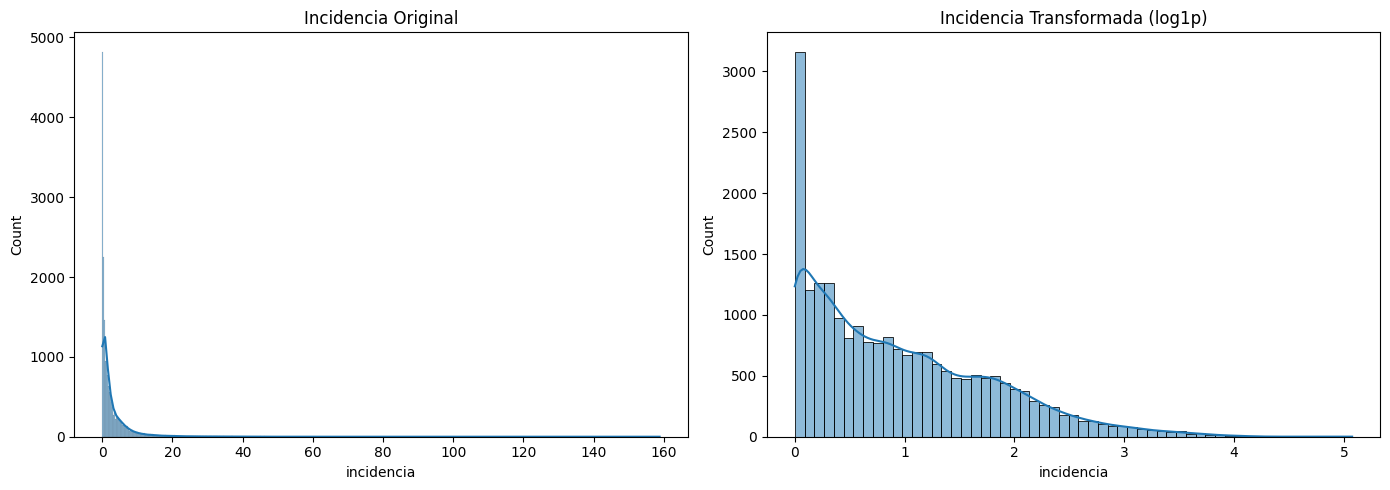

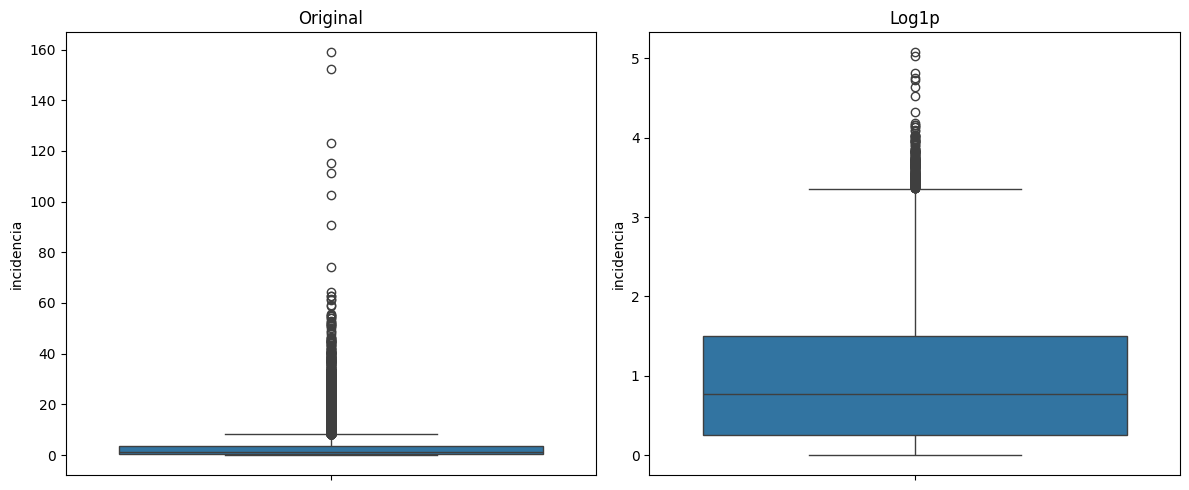

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["incidencia"],
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Incidencia Original")

sns.histplot(
    np.log1p(df["incidencia"]),
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Incidencia Transformada (log1p)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["incidencia"], ax=axes[0])
axes[0].set_title("Original")

sns.boxplot(y=np.log1p(df["incidencia"]), ax=axes[1])
axes[1].set_title("Log1p")

plt.tight_layout()
plt.show()

### **6.3.3. Grafo Espacial**

In [13]:
departments = sorted(df["departamento"].unique())

dept_to_idx = {d: i for i, d in enumerate(departments)}

idx_to_dept = {i: d for d, i in dept_to_idx.items()}

NUM_NODES = len(departments)

gdf = gpd.read_file(
    "/home/guirlessa/Dl_Proyecto_Dengue/Covariables/MGN_ADM_DPTO_POLITICO/MGN_ADM_DPTO_POLITICO_limpio.shp"
)

gdf = gdf.set_index("dpto_cnmbr").loc[departments].reset_index()


def build_queen_adj(gdf, departments):

    w   = Queen.from_dataframe(gdf)
    adj = np.zeros(
        (len(departments), len(departments)),
        dtype=np.float32
    )

    for i, neighbors in w.neighbors.items():
        for j in neighbors:
            adj[i, j] = 1.0

    np.fill_diagonal(adj, 1.0)

    return adj


def normalize_adj(adj):

    D = np.diag(np.power(adj.sum(axis=1), -0.5))

    return (D @ adj @ D).astype(np.float32)


adj_raw        = build_queen_adj(gdf, departments)
adj_normalized = normalize_adj(adj_raw)

adj_matrix = torch.tensor(
    adj_normalized,
    dtype=torch.float32
).to(DEVICE)

/tmp/ipykernel_109630/1012815684.py:26: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w   = Queen.from_dataframe(gdf)


### **6.3.4. Normaización de los Datos**

Se plantea la función scale_data con el fin de aplicar una normalización robusta (RobustScaler) a los datos de entrenamiento y validación, para así preservar la estructura original de series temporales multivariadas. Para ello, primero reestructura los tensores a dos dimensiones para ajustar el escalador únicamente sobre el conjunto de entrenamiento, evitando *data leakage*, y luego transforma ambos conjuntos antes de devolverlos a su forma original.

In [12]:
def scale_data(X_train, X_val):

    scaler = RobustScaler()

    _, _, _, n_features = X_train.shape

    X_train_2d = X_train.reshape(-1, n_features)

    scaler.fit(X_train_2d)

    X_train_scaled = scaler.transform(X_train_2d).reshape(X_train.shape)

    X_val_scaled = scaler.transform(
        X_val.reshape(-1, n_features)
    ).reshape(X_val.shape)

    return X_train_scaled, X_val_scaled, scaler

## **6.4. Esquema de validación temporal**

Se implementa un esquema de validación cruzada temporal anidada (nested time series cross-validation), en el cual los datos se dividen respetando estrictamente el orden cronológico para evitar *data leakage*. En el nivel externo, se definen particiones de entrenamiento y prueba por año (2022–2024), simulando un escenario real de predicción futura; mientras que en el nivel interno, el conjunto de entrenamiento se subdivide nuevamente en conjuntos de entrenamiento y validación (2019–2021) para ajuste de hiperparámetros y selección de modelos. Este enfoque garantiza una evaluación más robusta y realista al emular la dinámica de predicción en series temporales.

In [14]:
def create_outer_folds(df, date_col="fecha_inicio"):

    folds       = []
    outer_years = [2022, 2023, 2024]

    for test_year in outer_years:

        train_df = df[df[date_col].dt.year <  test_year].copy()
        test_df  = df[df[date_col].dt.year == test_year].copy()

        folds.append({
            "test_year": test_year,
            "train_df":  train_df,
            "test_df":   test_df
        })

    return folds


outer_folds = create_outer_folds(df)

In [15]:
def create_inner_folds(train_df, val_years=[2019, 2020, 2021]):

    inner_folds = []

    for val_year in val_years:

        inner_train = train_df[
            train_df["fecha_inicio"].dt.year < val_year
        ].copy()

        inner_val = train_df[
            train_df["fecha_inicio"].dt.year == val_year
        ].copy()

        inner_folds.append({
            "val_year":    val_year,
            "inner_train": inner_train,
            "inner_val":   inner_val
        })

    return inner_folds

## **6.5. Ventanas de Tiempo**

Esta función implementa la construcción del conjunto de datos supervisado para modelado espaciotemporal, mediante la transformación de datos tabulares en tensores estructurados compatibles con arquitecturas de aprendizaje profundo. En primer lugar, reorganiza las variables explicativas y la variable objetivo a través de tablas pivote indexadas por fecha y departamento, asegurando consistencia en la representación espacial. Posteriormente, se unifican las variables en un tensor multivariado y se genera una estructura de secuencias mediante una estrategia de ventanas deslizantes (sliding windows), en la que se define explícitamente un historial de observación (window_size) y un horizonte de predicción (horizon). Finalmente, se preserva información auxiliar como las fechas de referencia y el orden de los departamentos, lo cual es fundamental para mantener la coherencia temporal y espacial del conjunto de datos.

In [16]:
def create_windows(
    df,
    features,
    target,
    window_size=12,
    horizon=4
):

    pivot_features = []

    for feat in features:

        pivot = df.pivot_table(
            index="fecha_inicio",
            columns="departamento",
            values=feat
        ).sort_index()

        pivot_features.append(pivot.values)

    X_all = np.stack(pivot_features, axis=-1)

    target_pivot = df.pivot_table(
        index="fecha_inicio",
        columns="departamento",
        values=target
    ).sort_index()

    y_all = target_pivot.values
    dates = target_pivot.index.values

    X          = []
    y          = []
    base_dates = []

    total_steps = len(dates)

    for i in range(total_steps - window_size - horizon + 1):

        X.append(X_all[i : i + window_size])

        y.append(y_all[i + window_size : i + window_size + horizon])

        base_dates.append(dates[i + window_size - 1])

    X          = np.array(X, dtype=np.float32)
    y          = np.array(y, dtype=np.float32)
    base_dates = np.array(base_dates)

    return X, y, base_dates

## **6.6. Funciones para el Modelado**

La clase EarlyStopping introduce un mecanismo de regularización basado en la detención anticipada del entrenamiento cuando la pérdida de validación deja de mejorar durante un número determinado de épocas (patience), lo cual ayuda a prevenir sobreajuste.

In [ ]:
class EarlyStopping:

    def __init__(self, patience=20):

        self.patience  = patience
        self.best_loss = np.inf
        self.counter   = 0
        self.stop      = False

    def step(self, val_loss):

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


Por otro lado, train_one_epoch y validate_one_epoch definen los ciclos estándar de entrenamiento y evaluación por época, respectivamente: la primera realiza la optimización del modelo mediante retropropagación del error, actualización de parámetros y recorte de gradientes para estabilizar el aprendizaje, mientras que la segunda evalúa el desempeño del modelo en modo inferencia sin actualización de pesos, permitiendo monitorear su generalización.

In [17]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()
    total_loss = 0

    for X_batch, y_batch in dataloader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred = model(X_batch, adj_matrix)

        loss = criterion(pred, y_batch)

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [18]:
def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()
    total_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in dataloader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch, adj_matrix)

            loss = criterion(pred, y_batch)

            total_loss += loss.item()

    return total_loss / len(dataloader)

## **6.7. Arquitectura**

In [ ]:
class Dataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [ ]:
class GraphConvolution(nn.Module):

    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, adj):
        """
        x: (batch, nodes, features)
        adj: (nodes, nodes)
        """

        x = torch.matmul(adj, x) 
        return self.linear(x)

In [27]:
class STGNN(nn.Module):

    def __init__(
        self,
        num_nodes,
        in_channels,
        hidden_size=64,
        horizon=4,
        dropout=0.1
    ):
        super().__init__()

        self.num_nodes = num_nodes
        self.hidden_size = hidden_size
        self.horizon = horizon

        # -------- Spatial --------
        self.gcn1 = GraphConvolution(in_channels, hidden_size)
        self.gcn2 = GraphConvolution(hidden_size, hidden_size)

        # -------- Temporal --------
        self.lstm = nn.LSTM(
            input_size=hidden_size * num_nodes,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

        # -------- Output --------
        self.head = nn.Linear(hidden_size, horizon * num_nodes)

    def forward(self, x, adj):
        """
        x: (B, T, N, F)
        """

        B, T, N, F = x.shape

        spatial_out = []

        # -------- temporal loop --------
        for t in range(T):

            x_t = x[:, t, :, :]  # (B, N, F)

            x_t = torch.relu(self.gcn1(x_t, adj))
            x_t = torch.relu(self.gcn2(x_t, adj))

            spatial_out.append(x_t)

        # (B, T, N, H)
        x = torch.stack(spatial_out, dim=1)

        # flatten nodes
        x = x.reshape(B, T, N * self.hidden_size)

        # temporal modeling
        out, _ = self.lstm(x)

        out = self.dropout(out[:, -1, :])  # last step

        out = self.head(out)

        # reshape to (B, horizon, nodes)
        out = out.view(B, self.horizon, N)

        return out

## **6.8. Optimización de Hiperparametros**

Inicializamos el entorno experimental del pipeline de optimización y evaluación del modelo,  definiendo estructuras globales para almacenar resultados de múltiples etapas del experimento (tuning, validación cruzada, entrenamiento y evaluación final).

In [ ]:
ALL_OPTUNA_TRIALS = []
ALL_OPTUNA_FOLDS = []
ALL_RESIDUALS = []
ALL_INFERENCE_TIME = []
ALL_BEST_PARAMS = []
ALL_RESULTS     = []
ALL_PREDICTIONS = []
ALL_LOSSES      = []

TUNING_DF = df[df["fecha_inicio"].dt.year < 2022].copy()

INNER_FOLDS_TUNING = create_inner_folds(
    TUNING_DF,
    val_years=[2019, 2020, 2021]
)

Ahora, definimos **objetivo de optimización para el ajuste de hiperparámetros mediante Optuna**, evaluando distintas configuraciones del modelo STGNN. Para cada *trial*, se muestrean hiperparámetros como tamaño de ventana, tasa de aprendizaje, tamaño de lote, número de capas, unidades ocultas, tamaño de kernel y *dropout*, y se evalúan mediante validación cruzada en los *inner folds*. En cada partición se entrena el modelo, se aplica *early stopping* y se calcula el RMSE sobre el conjunto de validación, retornando finalmente el error promedio como métrica a minimizar.

In [ ]:
def objective(trial):

    window_size = trial.suggest_categorical(
        "window_size", [4, 8, 12, 16]
    )

    learning_rate = trial.suggest_float(
        "learning_rate", 1e-4, 1e-2, log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size", [16, 32]
    )

    hidden_size = trial.suggest_categorical(
        "hidden_size", [32, 64, 128]
    )

    num_layers = trial.suggest_int(
        "num_layers", 1, 3
    )

    kernel_size = trial.suggest_categorical(
        "kernel_size", [3, 5, 7]
    )

    dropout = trial.suggest_float(
        "dropout", 0.0, 0.4, step=0.1
    )

    rmse_folds = []
    fold_errors = []

    for fold_id, fold in enumerate(INNER_FOLDS_TUNING):

        X_train, y_train, _ = create_windows(
            fold["inner_train"],
            FEATURES,
            TARGET,
            window_size,
            4
        )

        X_val, y_val, _ = create_windows(
            fold["inner_val"],
            FEATURES,
            TARGET,
            window_size,
            4
        )

        X_train_scaled, X_val_scaled, _ = scale_data(X_train, X_val)

        train_dataset = Dataset(X_train_scaled, y_train)
        val_dataset   = Dataset(X_val_scaled, y_val)

        g.manual_seed(seed)

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=False,
            worker_init_fn=seed_worker,
            generator=g
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False
        )

        model = STGNN(
            num_nodes=NUM_NODES,
            in_channels=len(FEATURES),
            hidden_size=hidden_size,
            horizon=4,
            dropout=dropout
        ).to(DEVICE)

        criterion = nn.MSELoss()

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

        early_stopping = EarlyStopping(patience=10)

        for epoch in range(50):

            train_one_epoch(
                model, train_loader, criterion, optimizer, DEVICE
            )

            val_loss = validate_one_epoch(
                model, val_loader, criterion, DEVICE
            )

            early_stopping.step(val_loss)

            if early_stopping.stop:
                break

        model.eval()

        preds = []
        trues = []

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                pred = model(X_batch.to(DEVICE), adj_matrix)

                preds.append(pred.cpu().numpy())
                trues.append(y_batch.numpy())

        preds = np.concatenate(preds)
        trues = np.concatenate(trues)

        errors = trues - preds

        rmse = np.sqrt(
            mean_squared_error(trues.flatten(), preds.flatten())
        )

        rmse_folds.append(rmse)

        fold_errors.append({
            "trial": trial.number,
            "seed": seed,
            "fold": fold_id,
            "rmse": rmse,
            "error_mean": float(np.mean(errors)),
            "error_std": float(np.std(errors))
        })

    rmse_mean = float(np.mean(rmse_folds))
    rmse_std  = float(np.std(rmse_folds))

    ALL_OPTUNA_TRIALS.append({
        "trial": trial.number,
        "seed": seed,
        "window_size": window_size,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "kernel_size": kernel_size,
        "dropout": dropout,
        "rmse_mean": rmse_mean,
        "rmse_std": rmse_std
    })

    ALL_OPTUNA_FOLDS.extend(fold_errors)

    trial.set_user_attr("rmse_folds", rmse_folds)
    trial.set_user_attr("rmse_std", rmse_std)

    return rmse_mean

## **6.9. Pipeline Train, Validation & Test**

Ahora se procede a ejecutar el ciclo completo de entrenamiento, optimización y evaluación del modelo STGNN bajo un esquema de validación cruzada temporal anidada. En este proceso, se realiza la búsqueda de hiperparámetros mediante Optuna para cada semilla, seguida del entrenamiento del modelo en los *outer folds* utilizando la mejor configuración obtenida. Finalmente, se evalúa el desempeño en el conjunto de prueba mediante métricas de error, registrando adicionalmente tiempos de entrenamiento e inferencia, así como predicciones y residuos para su análisis detallado posterior.

In [ ]:
for seed in SEEDS:

    print("\n")
    print("="*100)
    print(f"SEED {seed}")
    print("="*100)

    set_seed(seed)

    sampler = optuna.samplers.TPESampler(seed=seed)

    study = optuna.create_study(
        direction="minimize",
        sampler=sampler
    )

    study.optimize(objective, n_trials=30)

    best_params = study.best_trial.params

    print(f"\nMejores hiperparámetros para seed {seed}:")
    print(best_params)

    pd.DataFrame([{"seed": seed, **best_params}]).to_csv(
        f"/home/guirlessa/Dl_Proyecto_Dengue/Modelos/STGNN/stgnn_best_params_seed_{seed}.csv",
        index=False
    )

    ALL_BEST_PARAMS.append({"seed": seed, **best_params})

    for outer_idx, outer_fold in enumerate(outer_folds):

        print("\n")
        print("="*100)
        print(f"OUTER FOLD {outer_idx+1} | Test year: {outer_fold['test_year']}")
        print("="*100)

        outer_train_df = outer_fold["train_df"]
        final_test_df  = outer_fold["test_df"]

        window_size   = best_params["window_size"]
        hidden_size   = best_params["hidden_size"]
        num_layers    = best_params["num_layers"]
        kernel_size   = best_params["kernel_size"]
        dropout       = best_params["dropout"]
        learning_rate = best_params["learning_rate"]
        batch_size    = best_params["batch_size"]

        val_year = outer_train_df["fecha_inicio"].dt.year.max()

        final_train_df = outer_train_df[
            outer_train_df["fecha_inicio"].dt.year < val_year
        ]

        final_val_df = outer_train_df[
            outer_train_df["fecha_inicio"].dt.year == val_year
        ]

        X_train, y_train, train_dates = create_windows(
            final_train_df, FEATURES, TARGET, window_size, 4
        )

        X_val, y_val, val_dates = create_windows(
            final_val_df, FEATURES, TARGET, window_size, 4
        )

        X_test, y_test, test_dates = create_windows(
            final_test_df, FEATURES, TARGET, window_size, 4
        )

        X_train_scaled, X_val_scaled, scaler = scale_data(X_train, X_val)

        X_test_scaled = scaler.transform(
            X_test.reshape(-1, X_test.shape[-1])
        ).reshape(X_test.shape)

        train_dataset = Dataset(X_train_scaled, y_train)
        val_dataset   = Dataset(X_val_scaled,   y_val)
        test_dataset  = Dataset(X_test_scaled,  y_test)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
        test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

        model = STGNN(
            num_nodes=NUM_NODES,
            in_channels=len(FEATURES),
            hidden_size=hidden_size,
            horizon=4,
            dropout=dropout
        ).to(DEVICE)

        criterion = nn.MSELoss()

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=10
        )

        early_stopping = EarlyStopping(patience=20)

        best_model = None
        best_loss = np.inf

        total_train_time = 0.0

        for epoch in range(300):

            start_epoch = time.time()

            train_loss = train_one_epoch(
                model, train_loader, criterion, optimizer, DEVICE
            )

            val_loss = validate_one_epoch(
                model, val_loader, criterion, DEVICE
            )

            scheduler.step(val_loss)

            epoch_time = time.time() - start_epoch
            total_train_time += epoch_time

            print(
                f"Epoch {epoch+1}"
                f" | Train {train_loss:.4f}"
                f" | Val {val_loss:.4f}"
                f" | Time {epoch_time:.2f}s"
            )

            ALL_LOSSES.append({
                "seed": seed,
                "outer_fold": outer_idx + 1,
                "test_year": outer_fold["test_year"],
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "epoch_time": epoch_time
            })

            if val_loss < best_loss:
                best_loss = val_loss
                best_model = copy.deepcopy(model)

            early_stopping.step(val_loss)

            if early_stopping.stop:
                break

        model = best_model

        torch.save(
            model.state_dict(),
            f"/home/guirlessa/Dl_Proyecto_Dengue/Modelos/STGNN/"
            f"stgnn_seed_{seed}_outer_fold_{outer_idx+1}.pt"
        )

        model.eval()

        start_inference = time.time()

        predictions = []
        targets = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:

                X_batch = X_batch.to(DEVICE)

                pred = model(X_batch, adj_matrix)

                predictions.append(pred.cpu().numpy())
                targets.append(y_batch.numpy())

        inference_time = time.time() - start_inference

        predictions = np.concatenate(predictions)
        targets     = np.concatenate(targets)

        mse  = mean_squared_error(targets.flatten(), predictions.flatten())
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(targets.flatten(), predictions.flatten())
        r2   = r2_score(targets.flatten(), predictions.flatten())

        ALL_RESULTS.append({
            "seed": seed,
            "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "mse": mse,
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
            "train_time": total_train_time,
            "inference_time": inference_time
        })

        ALL_INFERENCE_TIME.append({
            "seed": seed,
            "outer_fold": outer_idx + 1,
            "test_year": outer_fold["test_year"],
            "inference_time": inference_time,
            "train_time": total_train_time
        })


        rows = []

        for i in range(len(predictions)):
            for h in range(4):
                for node in range(NUM_NODES):

                    y_true = targets[i, h, node]
                    y_pred = predictions[i, h, node]

                    residual = y_true - y_pred

                    rows.append({
                        "seed": seed,
                        "outer_fold": outer_idx + 1,
                        "test_year": outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base": test_dates[i],
                        "horizonte": h + 1,

                        "y_true_log": y_true,
                        "y_pred_log": y_pred,

                        "y_true_real": np.expm1(y_true),
                        "y_pred_real": np.expm1(y_pred),

                        "residual": residual,
                        "abs_error": abs(residual),
                        "sq_error": residual ** 2
                    })

                    ALL_RESIDUALS.append({
                        "seed": seed,
                        "outer_fold": outer_idx + 1,
                        "test_year": outer_fold["test_year"],
                        "departamento": idx_to_dept[node],
                        "fecha_base": test_dates[i],
                        "horizonte": h + 1,
                        "residual": residual
                    })

        ALL_PREDICTIONS.append(pd.DataFrame(rows))

[I 2026-06-01 15:11:17,741] A new study created in memory with name: no-name-186847fd-dc11-427a-b64b-1fc8d69ee714




SEED 42
Seed fijada: 42


[I 2026-06-01 15:11:38,706] Trial 0 finished with value: 0.7020738918478192 and parameters: {'window_size': 8, 'learning_rate': 0.0002051338263087451, 'batch_size': 16, 'hidden_size': 32, 'num_layers': 1, 'kernel_size': 3, 'dropout': 0.0}. Best is trial 0 with value: 0.7020738918478192.
[I 2026-06-01 15:11:59,595] Trial 1 finished with value: 0.6843161100453679 and parameters: {'window_size': 12, 'learning_rate': 0.0003823475224675188, 'batch_size': 16, 'hidden_size': 128, 'num_layers': 3, 'kernel_size': 7, 'dropout': 0.0}. Best is trial 1 with value: 0.6843161100453679.
[I 2026-06-01 15:12:23,079] Trial 2 finished with value: 0.8042434475465106 and parameters: {'window_size': 16, 'learning_rate': 0.00853618986286683, 'batch_size': 16, 'hidden_size': 64, 'num_layers': 1, 'kernel_size': 7, 'dropout': 0.1}. Best is trial 1 with value: 0.6843161100453679.
[I 2026-06-01 15:12:43,001] Trial 3 finished with value: 0.6872289199381351 and parameters: {'window_size': 4, 'learning_rate': 0.00023


Mejores hiperparámetros para seed 42:
{'window_size': 16, 'learning_rate': 0.0027324685838808938, 'batch_size': 32, 'hidden_size': 64, 'num_layers': 1, 'kernel_size': 5, 'dropout': 0.30000000000000004}


OUTER FOLD 1 | Test year: 2022
Epoch 1 | Train 0.8295 | Val 0.5068 | Time 0.21s
Epoch 2 | Train 0.4588 | Val 0.4566 | Time 0.18s
Epoch 3 | Train 0.3687 | Val 0.5325 | Time 0.17s
Epoch 4 | Train 0.3400 | Val 0.4689 | Time 0.17s
Epoch 5 | Train 0.3180 | Val 0.4404 | Time 0.18s
Epoch 6 | Train 0.3160 | Val 0.4373 | Time 0.18s
Epoch 7 | Train 0.3051 | Val 0.4121 | Time 0.17s
Epoch 8 | Train 0.2822 | Val 0.3821 | Time 0.18s
Epoch 9 | Train 0.2626 | Val 0.3841 | Time 0.17s
Epoch 10 | Train 0.2429 | Val 0.3465 | Time 0.18s
Epoch 11 | Train 0.2280 | Val 0.3414 | Time 0.18s
Epoch 12 | Train 0.2219 | Val 0.3441 | Time 0.17s
Epoch 13 | Train 0.2084 | Val 0.3470 | Time 0.17s
Epoch 14 | Train 0.2087 | Val 0.3352 | Time 0.18s
Epoch 15 | Train 0.1994 | Val 0.3413 | Time 0.18s
Epoch 16 | Train 0.1946

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


...

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


Epoch 1 | Train 0.8128 | Val 0.7136 | Time 0.22s
Epoch 2 | Train 0.4671 | Val 0.6040 | Time 0.20s
Epoch 3 | Train 0.3754 | Val 0.5246 | Time 0.20s
Epoch 4 | Train 0.3360 | Val 0.5149 | Time 0.20s
Epoch 5 | Train 0.3126 | Val 0.4836 | Time 0.19s
Epoch 6 | Train 0.2892 | Val 0.4395 | Time 0.20s
Epoch 7 | Train 0.2699 | Val 0.4249 | Time 0.18s
Epoch 8 | Train 0.2532 | Val 0.4161 | Time 0.19s
Epoch 9 | Train 0.2567 | Val 0.4345 | Time 0.20s
Epoch 10 | Train 0.2784 | Val 0.4018 | Time 0.20s
Epoch 11 | Train 0.2398 | Val 0.3941 | Time 0.21s
Epoch 12 | Train 0.2267 | Val 0.4205 | Time 0.20s
Epoch 13 | Train 0.2132 | Val 0.4193 | Time 0.19s
Epoch 14 | Train 0.1982 | Val 0.4009 | Time 0.22s
Epoch 15 | Train 0.1874 | Val 0.4299 | Time 0.21s
Epoch 16 | Train 0.1838 | Val 0.4562 | Time 0.24s
Epoch 17 | Train 0.1743 | Val 0.3884 | Time 0.17s
Epoch 18 | Train 0.1754 | Val 0.4622 | Time 0.17s
Epoch 19 | Train 0.1740 | Val 0.4572 | Time 0.17s
Epoch 20 | Train 0.1753 | Val 0.4002 | Time 0.17s
Epoch 21 

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(




OUTER FOLD 3 | Test year: 2024
Epoch 1 | Train 0.8170 | Val 1.0055 | Time 0.20s
Epoch 2 | Train 0.4587 | Val 0.7159 | Time 0.20s
Epoch 3 | Train 0.3894 | Val 0.5738 | Time 0.21s
Epoch 4 | Train 0.3518 | Val 0.5683 | Time 0.19s
Epoch 5 | Train 0.3296 | Val 0.5570 | Time 0.20s
Epoch 6 | Train 0.3101 | Val 0.5977 | Time 0.25s
Epoch 7 | Train 0.2857 | Val 0.6336 | Time 0.24s
Epoch 8 | Train 0.2613 | Val 0.6948 | Time 0.26s
Epoch 9 | Train 0.2521 | Val 0.5366 | Time 0.27s
Epoch 10 | Train 0.2563 | Val 0.5324 | Time 0.22s
Epoch 11 | Train 0.2553 | Val 0.6201 | Time 0.21s
Epoch 12 | Train 0.2257 | Val 0.7039 | Time 0.22s
Epoch 13 | Train 0.2217 | Val 0.5330 | Time 0.20s
Epoch 14 | Train 0.2089 | Val 0.5508 | Time 0.25s
Epoch 15 | Train 0.2074 | Val 0.7523 | Time 0.23s
Epoch 16 | Train 0.2002 | Val 0.6193 | Time 0.22s
Epoch 17 | Train 0.1842 | Val 0.5356 | Time 0.18s
Epoch 18 | Train 0.1827 | Val 0.7159 | Time 0.21s
Epoch 19 | Train 0.1724 | Val 0.6159 | Time 0.22s
Epoch 20 | Train 0.1624 | 

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


In [ ]:
results_df        = pd.DataFrame(ALL_RESULTS)
predictions_df    = pd.concat(ALL_PREDICTIONS, axis=0)
losses_df         = pd.DataFrame(ALL_LOSSES)
best_params_df    = pd.DataFrame(ALL_BEST_PARAMS)

optuna_trials_df  = pd.DataFrame(ALL_OPTUNA_TRIALS)
optuna_folds_df   = pd.DataFrame(ALL_OPTUNA_FOLDS)

inference_df      = pd.DataFrame(ALL_INFERENCE_TIME)
residuals_df      = pd.DataFrame(ALL_RESIDUALS)

BASE_PATH = "/home/guirlessa/Dl_Proyecto_Dengue/Modelos/STGNN"

results_df.to_csv(f"{BASE_PATH}/stgnn_results.csv", index=False)

predictions_df.to_csv(
    f"{BASE_PATH}/stgnn_predictions.csv",
    index=False
)

losses_df.to_csv(
    f"{BASE_PATH}/stgnn_training_history.csv",
    index=False
)

best_params_df.to_csv(
    f"{BASE_PATH}/stgnn_best_params.csv",
    index=False
)

optuna_trials_df.to_csv(
    f"{BASE_PATH}/stgnn_optuna_trials.csv",
    index=False
)

optuna_folds_df.to_csv(
    f"{BASE_PATH}/stgnn_optuna_folds.csv",
    index=False
)

inference_df.to_csv(
    f"{BASE_PATH}/stgnn_inference_time.csv",
    index=False
)

residuals_df.to_csv(
    f"{BASE_PATH}/stgnn_residuals.csv",
    index=False
)

print("\n" + "="*100)
print("FINAL RESULTS")
print("="*100)

print(results_df.describe())


FINAL RESULTS
              seed  outer_fold    test_year       mse      rmse       mae  \
count     9.000000    9.000000     9.000000  9.000000  9.000000  9.000000   
mean    729.666667    2.000000  2023.000000  0.716476  0.823678  0.663051   
std     971.383421    0.866025     0.866025  0.359924  0.206842  0.178460   
min      42.000000    1.000000  2022.000000  0.378574  0.615284  0.490184   
25%      42.000000    1.000000  2022.000000  0.393871  0.627591  0.511833   
50%     123.000000    2.000000  2023.000000  0.626503  0.791520  0.618971   
75%    2024.000000    3.000000  2024.000000  1.009307  1.004643  0.826532   
max    2024.000000    3.000000  2024.000000  1.287457  1.134662  0.940242   

             r2  train_time  inference_time  
count  9.000000    9.000000        9.000000  
mean  -0.094875    6.488979        0.007068  
std    0.509273    0.957098        0.001605  
min   -0.911356    4.690310        0.005188  
25%   -0.424006    5.897321        0.005876  
50%   -0.031844

## **6.10. Evaluando Modelo**

In [19]:
MODEL_NAME = "STGNN"
BASE_PATH = "Modelos/STGNN"

results = pd.read_csv(f"{BASE_PATH}/stgnn_results.csv")
preds = pd.read_csv(f"{BASE_PATH}/stgnn_predictions.csv")
residuals = pd.read_csv(f"{BASE_PATH}/stgnn_residuals.csv")
history = pd.read_csv(f"{BASE_PATH}/stgnn_training_history.csv")

In [20]:
def compute_metrics(df, col_true='y_true_real', col_pred='y_pred_real', col_seed='seed'):
    metrics = []
    for seed in df[col_seed].unique():
        subset = df[df[col_seed] == seed]

        rmse = np.sqrt(mean_squared_error(subset[col_true], subset[col_pred]))
        mae = mean_absolute_error(subset[col_true], subset[col_pred])
        r2 = r2_score(subset[col_true], subset[col_pred])

        metrics.append({
            'seed': seed,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        })

    return pd.DataFrame(metrics)


metrics_real = compute_metrics(preds)

print(metrics_real)

metrics_real.to_csv(f"{BASE_PATH}/metrics_stgnn.csv", index=False)

   seed      RMSE       MAE        R2
0    42  7.334999  4.101241 -0.073531
1   123  7.159085  3.981733  0.102631
2  2024  7.217204  4.062011 -0.039327


Los resultados del modelo STGNN muestran un desempeño limitado y poco consistente entre semillas. En promedio, el RMSE se sitúa alrededor de 7.23 y el MAE cerca de 4.05, valores similares a los observados en modelos menos eficientes. Sin embargo, el R² presenta valores cercanos a cero e incluso negativos en algunas ejecuciones, lo que indica una baja capacidad explicativa e incluso un desempeño inferior al de un modelo base de referencia en ciertos casos. En conjunto, estos resultados sugieren que el STGNN no logra capturar de manera adecuada la estructura espacio-temporal del fenómeno bajo la configuración evaluada, evidenciando una alta variabilidad y una limitada capacidad predictiva.


In [4]:
summary_real = metrics_real[['RMSE','MAE','R2']].agg(['mean','std'])

print("\nResumen STGNN:\n", summary_real)


Resumen STGNN:
           RMSE       MAE        R2
mean  7.237096  4.048328 -0.003409
std   0.089629  0.060917  0.093412


El resumen global del modelo STGNN muestra un RMSE promedio de 7.24 y un MAE de 4.05, con una desviación estándar baja en ambas métricas, lo que indica cierta estabilidad en el error entre semillas. Sin embargo, el R² promedio de −0.003 evidencia una capacidad explicativa nula, e incluso ligeramente inferior a un modelo de referencia simple. Aunque la variabilidad entre ejecuciones es reducida, el desempeño general del modelo es débil, lo que sugiere que, bajo la configuración evaluada, el STGNN no logra capturar de manera efectiva la dinámica espacio-temporal de la serie.


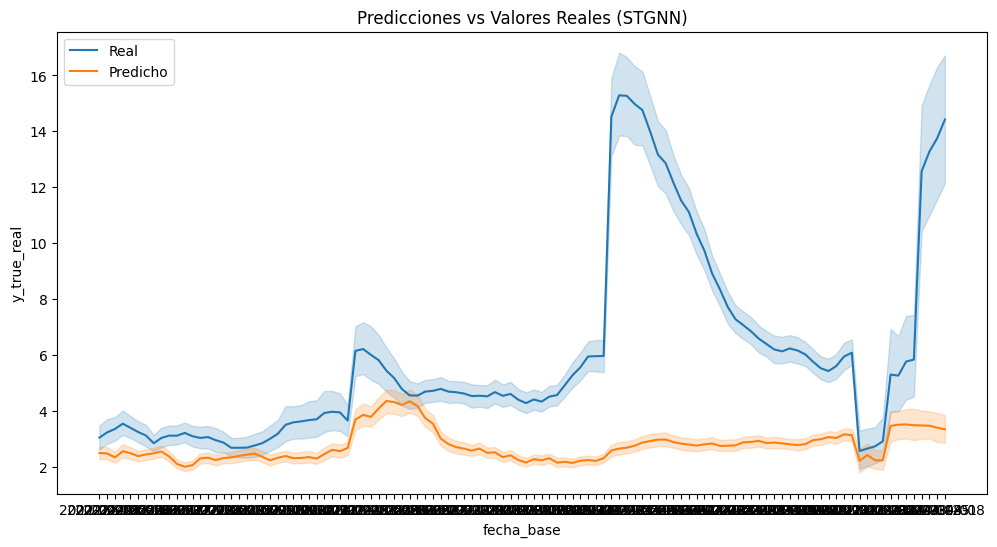

In [5]:
plt.figure(figsize=(12,6))
sns.lineplot(x='fecha_base', y='y_true_real', data=preds, label='Real')
sns.lineplot(x='fecha_base', y='y_pred_real', data=preds, label='Predicho')
plt.title("Predicciones vs Valores Reales (STGNN)")
plt.legend()
plt.show()

El gráfico de predicciones vs. valores reales del modelo STGNN evidencia una discrepancia persistente entre ambas series, donde el modelo logra capturar parcialmente la tendencia general de la serie temporal, pero presenta una subestimación sistemática de los valores observados, especialmente en los picos epidémicos. Mientras los datos reales alcanzan variaciones abruptas con máximos superiores a 16 unidades, las predicciones se mantienen en un rango más reducido y con menor amplitud, lo que indica una limitada capacidad para representar eventos extremos. Este comportamiento sugiere que, aunque el modelo conserva coherencia temporal y estabilidad en la dinámica general, su capacidad de modelar la magnitud de los brotes es reducida.


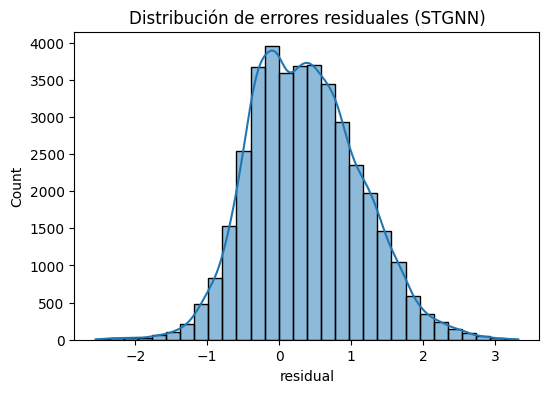

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(residuals['residual'], bins=30, kde=True)
plt.title("Distribución de errores residuales (STGNN)")
plt.show()

La distribución de los residuos del modelo STGNN presenta una forma aproximadamente normal y centrada en torno a cero, con cierta simetría y colas moderadas. Este comportamiento indica que los errores se distribuyen de manera mayoritariamente aleatoria, sin evidencias claras de sesgo sistemático hacia la sobreestimación o subestimación, lo que sugiere un ajuste estadísticamente razonable. La concentración de los residuos cerca de cero indica que una proporción importante de las predicciones se aproxima a los valores observados, mientras que los errores de mayor magnitud ocurren con menor frecuencia.

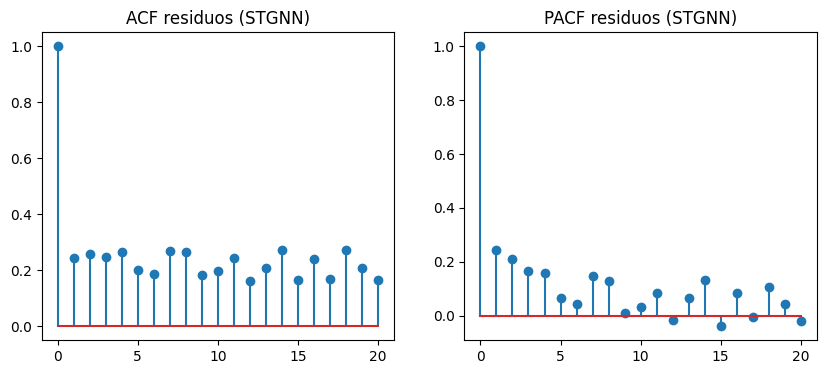

In [7]:
acf_vals = acf(residuals['residual'], nlags=20)
pacf_vals = pacf(residuals['residual'], nlags=20)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.stem(acf_vals)
plt.title("ACF residuos (STGNN)")

plt.subplot(1,2,2)
plt.stem(pacf_vals)
plt.title("PACF residuos (STGNN)")

plt.show()

Las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) de los residuos del modelo STGNN muestran valores bajos y sin patrones estructurados relevantes más allá del rezago cero, donde la autocorrelación es, por definición, igual a uno. Este comportamiento sugiere que no existe una dependencia temporal marcada en los errores, lo que es consistente con un comportamiento cercano a ruido blanco. En términos estadísticos, esto indica que el modelo no deja remanentes evidentes de estructura temporal sin explicar, lo cual respalda la adecuación del ajuste desde la perspectiva de independencia de los residuos. En conjunto, los resultados apoyan la validez del modelo en la representación de la dinámica espacio-temporal de la serie, al menos en lo relativo a la ausencia de autocorrelación residual significativa.


In [8]:
lb = acorr_ljungbox(residuals['residual'], lags=[10, 20], return_df=True)
print(lb)

         lb_stat  lb_pvalue
10  21481.453027        0.0
20  39498.294237        0.0


Los resultados de la prueba de Ljung-Box para los residuos del modelo STGNN muestran estadísticos elevados (21481.45 y 39498.29 para los rezagos 10 y 20, respectivamente) junto con valores p iguales a 0.0. Esto indica que se rechaza de manera contundente la hipótesis nula de ausencia de autocorrelación en los residuos. En consecuencia, se evidencia la presencia de dependencia temporal significativa en los errores, lo que sugiere que el modelo no logra capturar completamente toda la estructura temporal de la serie. Desde una perspectiva estadística, este resultado implica que los residuos no se comportan como ruido blanco, lo que limita la validez del ajuste del STGNN a pesar de su posible capacidad para capturar tendencias generales.


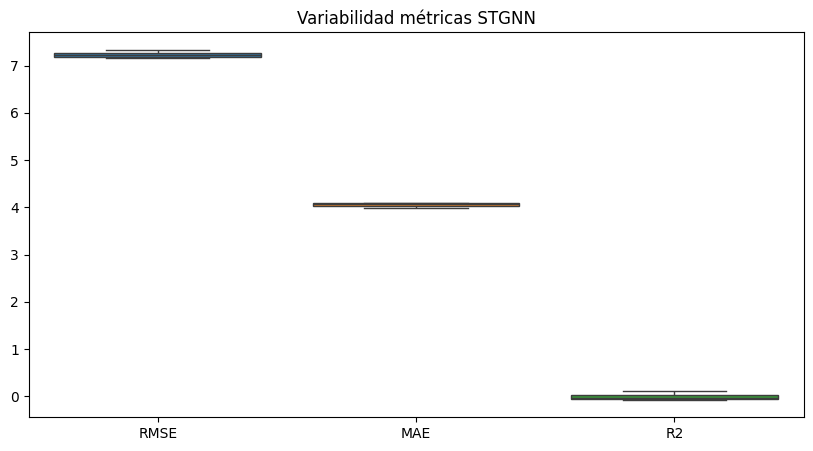

In [9]:
plt.figure(figsize=(10,5))
sns.boxplot(data=metrics_real[['RMSE','MAE','R2']])
plt.title("Variabilidad métricas STGNN")
plt.show()

El gráfico de variabilidad de métricas del modelo STGNN evidencia una alta consistencia del desempeño entre distintas semillas de inicialización. Las métricas presentan una dispersión reducida, lo que indica que los resultados son estables y reproducibles a lo largo de las diferentes ejecuciones. En términos cuantitativos, el RMSE se mantiene en torno a 7, el MAE alrededor de 4 y el R² cercano a cero, sin variaciones significativas entre corridas. Esta baja variabilidad sugiere que el modelo presenta una convergencia estable y que su comportamiento no depende de condiciones iniciales específicas. No obstante, el nivel relativamente bajo del R² indica una limitada capacidad explicativa de la variabilidad de la serie, lo que sugiere margen de mejora en la representación de las dependencias espacio-temporales o en la configuración de la arquitectura del modelo.


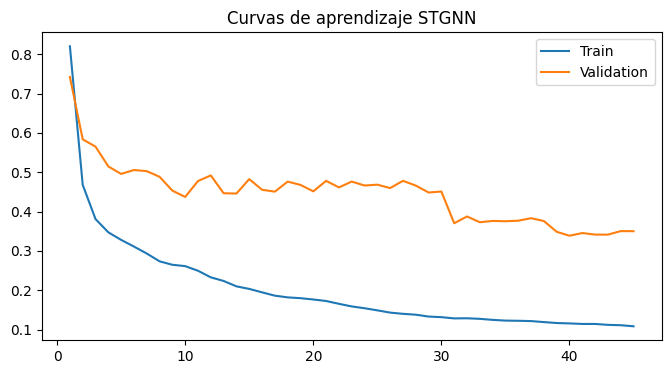

In [10]:
avg_history = history.groupby('epoch')[['train_loss','val_loss']].mean().reset_index()

plt.figure(figsize=(8,4))
plt.plot(avg_history['epoch'], avg_history['train_loss'], label='Train')
plt.plot(avg_history['epoch'], avg_history['val_loss'], label='Validation')
plt.title("Curvas de aprendizaje STGNN")
plt.legend()
plt.show()

Las curvas de aprendizaje del modelo STGNN muestran una convergencia estable durante el proceso de entrenamiento. La pérdida de entrenamiento disminuye de forma progresiva y sostenida hasta valores cercanos a 0.1, lo que indica que el modelo logra ajustar adecuadamente los patrones presentes en los datos. En paralelo, la pérdida de validación presenta una reducción inicial seguida de una estabilización alrededor de 0.35–0.4, con variaciones leves a lo largo de las épocas. Este comportamiento sugiere que el modelo alcanza un punto de equilibrio relativamente consistente entre ajuste y generalización, sin evidencia clara de sobreajuste severo. Las pequeñas fluctuaciones en la validación son esperables en este tipo de problemas espacio-temporales, donde la estructura de los datos puede introducir variabilidad entre lotes o periodos. En conjunto, el STGNN demuestra un proceso de aprendizaje correcto y una capacidad de generalización razonable, aunque la brecha persistente entre entrenamiento y validación indica que aún existe margen de mejora en la reducción del error fuera de muestra.


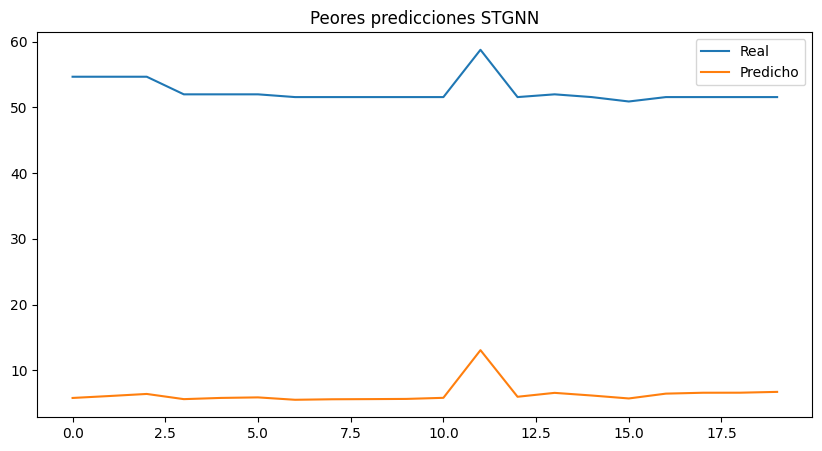

In [11]:
worst = preds.copy()
worst['error'] = abs(worst['y_true_real'] - worst['y_pred_real'])

worst_cases = worst.sort_values('error', ascending=False).head(20)

plt.figure(figsize=(10,5))
plt.plot(worst_cases['y_true_real'].values, label='Real')
plt.plot(worst_cases['y_pred_real'].values, label='Predicho')
plt.title("Peores predicciones STGNN")
plt.legend()
plt.show()

El gráfico de peores predicciones del modelo STGNN evidencia una subestimación sistemática y pronunciada de los valores observados. Mientras la serie real se mantiene en niveles cercanos a 55 unidades, las predicciones del modelo permanecen mayoritariamente entre 0 y 10, con un incremento puntual que no logra aproximarse a la magnitud del pico real. Este comportamiento indica que el modelo conserva cierta capacidad para seguir la estructura temporal general, pero falla de manera consistente en la representación de los episodios de alta incidencia.

Desde una perspectiva interpretativa, esta discrepancia sugiere que el STGNN tiende a suavizar excesivamente las predicciones, privilegiando la estabilidad global sobre la sensibilidad a eventos extremos. Como resultado, su desempeño se degrada en escenarios de alta variabilidad, donde los brotes epidémicos requieren una mayor capacidad de respuesta a cambios abruptos. En conjunto, el modelo muestra coherencia en la dinámica general, pero evidencia limitaciones importantes en la captura de magnitudes extremas, lo que apunta a la necesidad de reforzar su capacidad de adaptación mediante ajustes en la modelación de la pérdida o la incorporación de información adicional que mejore la representación de eventos críticos.


In [12]:
def mean_ci(series):
    mean = np.mean(series)
    sem = st.sem(series)
    ci = st.t.interval(0.95, len(series)-1, loc=mean, scale=sem)
    return mean, ci
import scipy.stats as st

rmse_mean, rmse_ci = mean_ci(metrics_real['RMSE'])
mae_mean, mae_ci = mean_ci(metrics_real['MAE'])
r2_mean, r2_ci = mean_ci(metrics_real['R2'])

print("RMSE:", rmse_mean, rmse_ci)
print("MAE:", mae_mean, mae_ci)
print("R2:", r2_mean, r2_ci)

RMSE: 7.237095998926093 (np.float64(7.0144463373661345), np.float64(7.4597456604860515))
MAE: 4.048328293417867 (np.float64(3.8970014101048633), np.float64(4.19965517673087))
R2: -0.003409079240440945 (np.float64(-0.2354576351118384), np.float64(0.2286394766309565))


Los resultados del modelo STGNN muestran un RMSE promedio de 7.24, con un intervalo entre 7.01 y 7.46, lo que indica un nivel de error relativamente alto pero estable entre semillas. El MAE promedio es de 4.05, con un rango estrecho entre 3.90 y 4.20, lo que refleja consistencia en el error absoluto a lo largo de las ejecuciones. Sin embargo, el R² promedio de −0.003, con un intervalo que va desde valores negativos hasta ligeramente positivos, evidencia una capacidad explicativa prácticamente nula, e incluso inferior a un modelo base en algunos casos. En conjunto, estos resultados sugieren que, aunque el modelo presenta estabilidad en sus errores, su desempeño global es limitado y no logra capturar de forma adecuada la variabilidad de la serie.
